In [2]:
import illustris_python as il
import numpy as np
import matplotlib.pyplot as plt

In [28]:
import scienceplots
plt.style.use('science')

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

In [6]:
def read_redshifts():
    filename = '/n/holylfs05/LABS/hernquist_lab/IllustrisTNG/Runs/L75n1820TNG/arepo/L75TNG_OutputList100.dat'
    scale_factors = []
    with open(filename, 'r') as file:
        for line in file:
            # Split the line and get the scale factor (first column)
            scale_factors.append(float(line.strip().split()[0]))

    # Convert to numpy array for efficient operations
    scale_factors = np.array(scale_factors)

    return 1/scale_factors - 1


In [34]:
base_path = '/n/holylfs05/LABS/hernquist_lab/IllustrisTNG/Runs/L75n1820TNG/output'

In [35]:
redshifts = read_redshifts()

In [90]:
snapshot = 13 
redshift = redshifts[snapshot]

In [91]:
redshift

5.9999999979

In [92]:
# select halos with at least 1000 particles
groups = il.groupcat.loadHalos(base_path,snapshot,fields=['GroupFirstSub', 'Group_M_Crit200'])

In [102]:
group_first_sub = groups['GroupFirstSub']
group_mass = groups['Group_M_Crit200']*1e10

mask = group_mass > 1e10

In [103]:

tree_base_path = '/n/holylfs05/LABS/hernquist_lab/IllustrisTNG/Runs/L75n1820TNG/postprocessing/trees/SubLink/'

In [104]:
mask.sum()

16883

Text(0, 0.5, 'Mass')

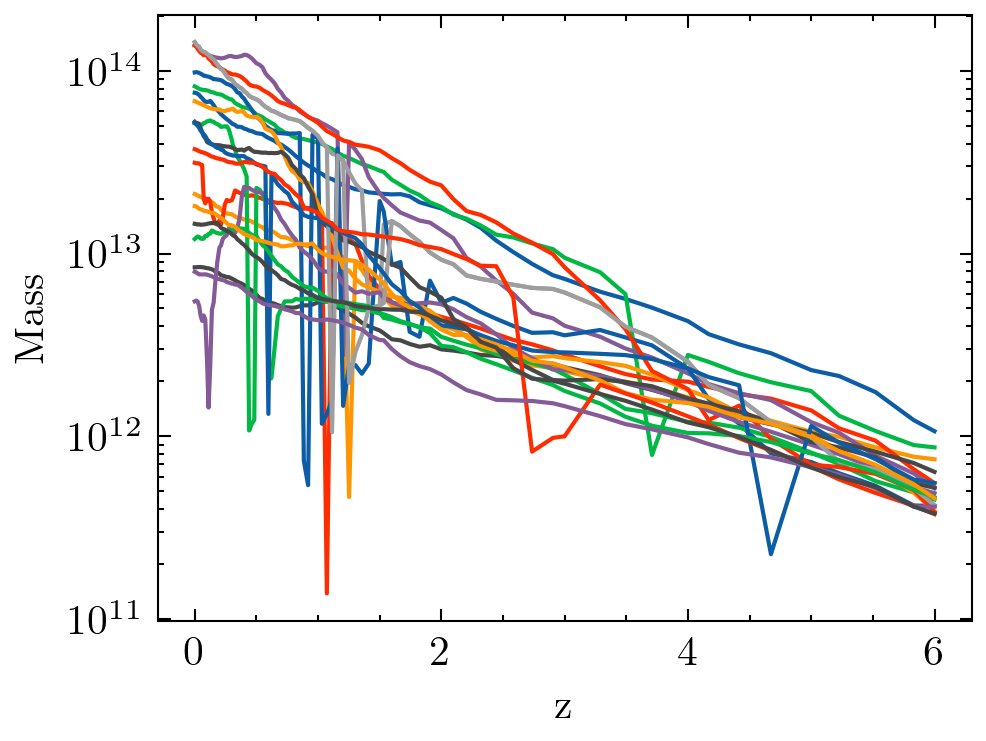

In [112]:
fields = ['SubhaloMass','SubfindID','SnapNum']

start = 0 

for i in range(start,start+20):
    tree = il.sublink.loadTree(base_path,snapshot,group_first_sub[mask][i],fields=fields,onlyMPB=False, onlyMDB=True)
    snapshots = tree['SnapNum']
    unique_snaps, idx = np.unique(tree['SnapNum'], return_index=True)
    if len(unique_snaps) != len(snapshots):
        print('Warning: Snapshots are not unique, keeping most massive only')
    max_masses = [np.max(tree['SubhaloMass'][tree['SnapNum'] == snap]) for snap in unique_snaps]
    clean_tree = {'SnapNum': unique_snaps, 'SubhaloMass': np.array(max_masses)}
    future_snapshot_mask = clean_tree['SnapNum'] >= snapshot
    z = [redshifts[s] for s in clean_tree['SnapNum'][future_snapshot_mask]]
    plt.plot(z,clean_tree['SubhaloMass'][future_snapshot_mask]*1e10,'-')
plt.yscale('log')
plt.xlabel('z')
plt.ylabel('Mass')


99 28592
100 80598
100 6954
100 79617
100 129983
100 15238


Text(0, 0.5, 'Mass')

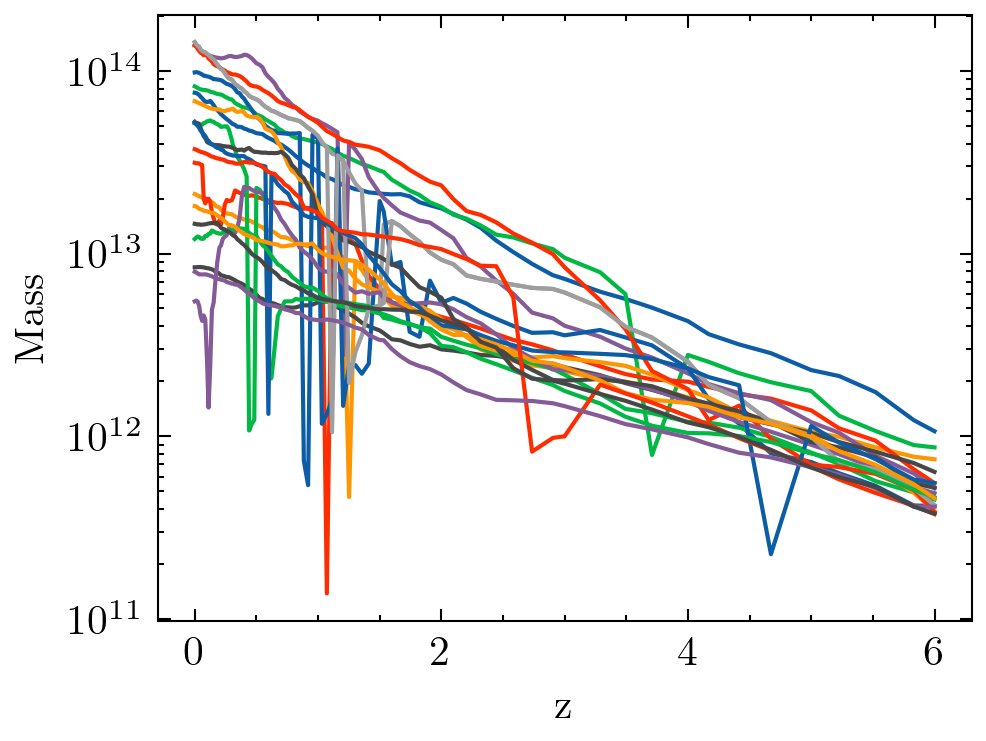

In [133]:
fields = ['SubhaloMass','SubfindID','SnapNum']

start = 0 

for i in range(start,start+20):
    tree = il.sublink.loadTree(base_path,snapshot,group_first_sub[mask][i],fields=fields,onlyMPB=False, onlyMDB=True)
    snapshots = tree['SnapNum']
    unique_snaps, idx = np.unique(tree['SnapNum'], return_index=True)
    if len(unique_snaps) != len(snapshots):
        print(len(unique_snaps), len(snapshots))
        print('Warning: Snapshots are not unique, keeping most massive only')
    max_masses = [np.max(tree['SubhaloMass'][tree['SnapNum'] == snap]) for snap in unique_snaps]
    clean_tree = {'SnapNum': unique_snaps, 'SubhaloMass': np.array(max_masses)}
    future_snapshot_mask = clean_tree['SnapNum'] >= snapshot
    z = [redshifts[s] for s in clean_tree['SnapNum'][future_snapshot_mask]]
    plt.plot(z,clean_tree['SubhaloMass'][future_snapshot_mask]*1e10,'-')
plt.yscale('log')
plt.xlabel('z')
plt.ylabel('Mass')


In [122]:
mask.sum()

16883

In [123]:
initial_mass, final_mass = [], []
counter = 0
for i in range(5_000):
    tree = il.sublink.loadTree(base_path,snapshot,group_first_sub[mask][i],fields=fields,onlyMPB=False, onlyMDB=True)
    snapshots = tree['SnapNum']
    unique_snaps, idx = np.unique(tree['SnapNum'], return_index=True)
    if len(unique_snaps) != len(snapshots):
        print(len(unique_snaps), len(snapshots))
        print('Warning: Snapshots are not unique, keeping most massive only')
    max_masses = [np.max(tree['SubhaloMass'][tree['SnapNum'] == snap]) for snap in unique_snaps]
    clean_tree = {'SnapNum': unique_snaps, 'SubhaloMass': np.array(max_masses)}
    future_snapshot_mask = clean_tree['SnapNum'] >= snapshot
    masses = clean_tree['SubhaloMass'][future_snapshot_mask]*1e10
    initial_mass.append(masses[0])
    final_mass.append(masses[-1])

In [124]:
counter

3122

In [126]:
counter / 5_000

0.6244

Text(0, 0.5, 'Mass at z=0')

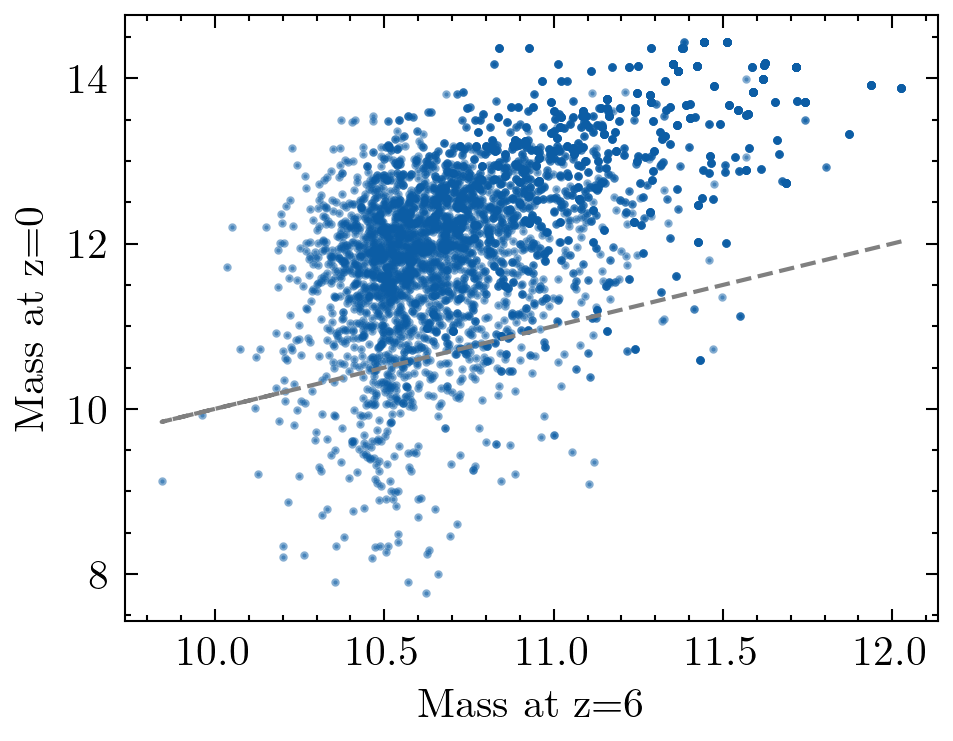

In [132]:
plt.scatter(np.log10(initial_mass), np.log10(final_mass), s=1, alpha=0.5)
plt.plot(np.log10(initial_mass), np.log10(initial_mass), linestyle='dashed',color='gray')
plt.xlabel('Mass at z=6')
plt.ylabel('Mass at z=0')